In [1]:
import torch
import torch.nn as nn
import tiktoken
from gptModel import GPTModel , GPT_CONFIG_24M

torch.Size([2, 3, 768])
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Input batch:
 []

Output shape: torch.Size([2, 3, 768])
tensor([[[ 0.0133,  0.0443, -0.1134,  ..., -0.1531,  0.0345,  0.1373],
         [-0.0827, -0.0400, -0.2275,  ..., -0.1586,  0.0444,  0.1835],
         [ 0.0289, -0.0046, -0.0328,  ..., -0.1257,  0.0283,  0.1537]],

        [[-0.0831,  0.0504, -0.1432,  ..., -0.1749,  0.0097,  0.2154],
         [-0.0700,  0.0501, -0.3218,  ..., -0.1854,  0.0695,  0.1163],
         [-0.1120,  0.1346, -0.1459,  ..., -0.0803,  0.1464,  0.0805]]],
       grad_fn=<ViewBackward0>)
Hello, I am Featureiman Byeswickattribute argue


In [2]:

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_24M)
model.eval();  

In [3]:
from gptModel import generate_text

In [4]:
import tiktoken
from gptModel import starting_context

def text_to_token_id(text, tokenizer):
    encode = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encode).unsqueeze(0)
    return encoded_tensor

def token_id_to_text(token_ids, tokenizer):
    flat=token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

starting_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_id = generate_text(model=model, idx=text_to_token_id(starting_context, tokenizer), max_token=10, context_size=GPT_CONFIG_24M['context_length'])

print("output: \n", token_id_to_text(token_id, tokenizer))

output: 
 Every effort moves you Aeiman Byeswickattributeometer inspector Normandy freezerigrate


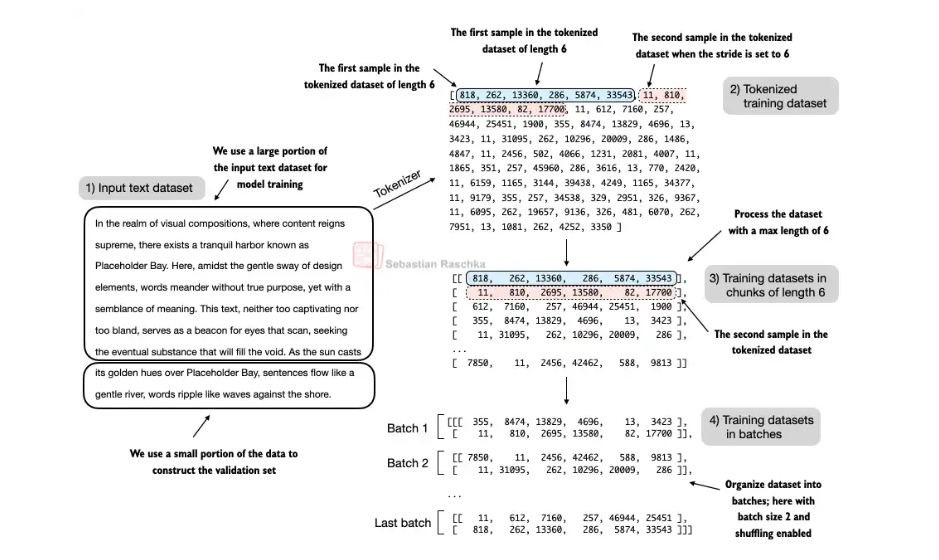

In [5]:
import os
import requests
file_path = "LLM/text.txt"
with open(file_path, "r", encoding="utf-8") as file:
    tex_data = file.read()

In [6]:
print(tex_data[:100])
print("character lenght: " ,len(tex_data))
print("token", len(tokenizer.encode(tex_data)))



Frankenstein;

or, the Modern Prometheus

by Mary Wollstonecraft (Godwin) Shelley


 CONTENTS

 L
character lenght:  419435
token 101757


- divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training


In [14]:
total_token = len(tokenizer.encode(tex_data))

In [15]:
from DataLoader import create_dataloader_v1

In [16]:
train_ratio = 0.90
split_idx = int(train_ratio*len(tex_data))
train_data = tex_data[:split_idx]
validate_data = tex_data[split_idx:]
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length= GPT_CONFIG_24M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0

)

In [17]:
if total_token * (train_ratio) < GPT_CONFIG_24M["context_length"]:
    print("Not enough token")
if total_token *(1-train_ratio) < GPT_CONFIG_24M["context_length"]:
    print("Not enough")


checking if the data loaded correctly